# E1 Experiment Analysis

In [1]:
import pathlib
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import matplotlib.pyplot as plt

In [43]:
EXPERIMENTS = {
    "e1_0_base": "Experiment 1.0 GCN",
    "e1_1_gat": "Experiment 1.1 GAT",
    "e1_2_gat_emb256": "Experiment  1.2 GAT emb256",
    # "e1_3_sched": "E1.3 Scheduler",
}

runs_dir = pathlib.Path("./runs")

In [44]:
def load_event_accumulator(run_path: pathlib.Path) -> EventAccumulator:
    subdirs = list(run_path.iterdir())
    if not subdirs:
        raise ValueError(f"No subdirectories in {run_path}")
    event_dir = subdirs[0]
    ea = EventAccumulator(str(event_dir))
    ea.Reload()
    return ea

def get_scalar_series(ea, tag):
    events = ea.Scalars(tag)
    steps = [e.step for e in events]
    values = [e.value for e in events]
    return steps, values

def get_final_scalar(ea, tag):
    events = ea.Scalars(tag)
    return events[-1].value

In [45]:
data = {}
for exp_name, exp_label in EXPERIMENTS.items():
    run_path = runs_dir / exp_name
    if not run_path.exists():
        print(f"Skipping {exp_name} - not found")
        continue
    ea = load_event_accumulator(run_path)
    data[exp_name] = {"label": exp_label, "ea": ea}
    print(f"Loaded {exp_name}")

Loaded e1_0_base
Loaded e1_1_gat
Loaded e1_2_gat_emb256


## Typst Table

In [46]:
print("#table(")
print("  columns: 4,")
print("  [Experiment], [Train], [Val], [Test],")
for exp_name, exp_data in data.items():
    ea = exp_data["ea"]
    label = exp_data["label"]
    try:
        train_err = get_final_scalar(ea, "translation_error/train_final")
    except KeyError:
        train_err = get_final_scalar(ea, "translation_error/train")
    try:
        val_err = get_final_scalar(ea, "translation_error/val_final")
    except KeyError:
        val_err = get_final_scalar(ea, "translation_error/val")
    test_err = get_final_scalar(ea, "translation_error/test")
    print(f"  [{label}], [{train_err:.4f}], [{val_err:.4f}], [{test_err:.4f}],")
print(")")

#table(
  columns: 4,
  [Experiment], [Train], [Val], [Test],
  [Experiment 1.0 GCN], [0.0468], [0.1038], [0.1135],
  [Experiment 1.1 GAT], [0.0370], [0.0794], [0.0768],
  [Experiment  1.2 GAT emb256], [0.0284], [0.0934], [0.0744],
)


## Loss Curves

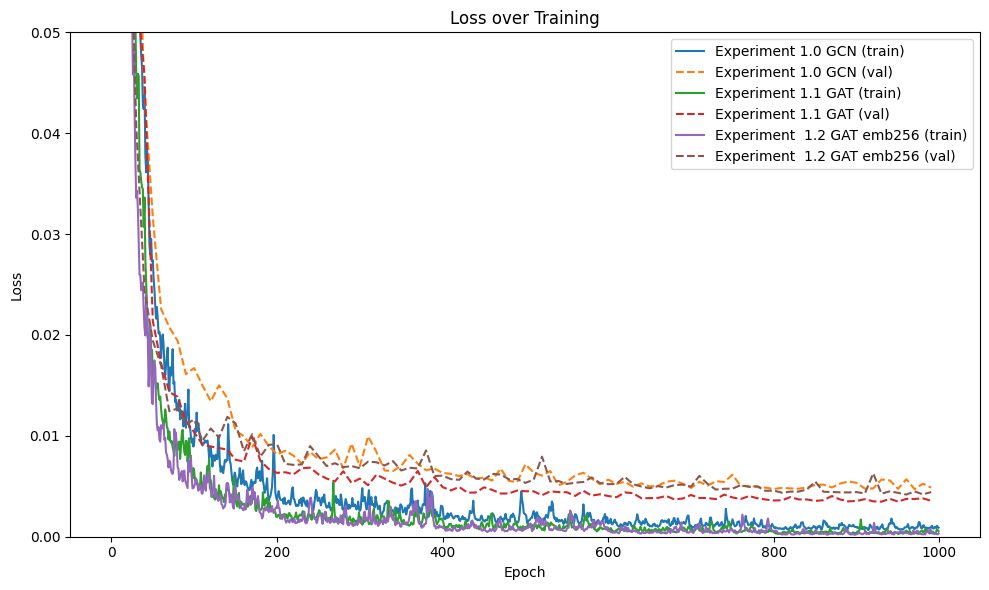

In [32]:
fig, ax = plt.subplots(figsize=(10, 6))
for exp_name, exp_data in data.items():
    ea = exp_data["ea"]
    label = exp_data["label"]
    steps, values = get_scalar_series(ea, "loss_all/train")
    ax.plot(steps, values, label=f"{label} (train)")
    steps, values = get_scalar_series(ea, "loss_all/val")
    ax.plot(steps, values, linestyle="--", label=f"{label} (val)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_ylim(0, 0.05)
ax.set_title("Loss over Training")
ax.legend()
plt.tight_layout()
plt.show()

## Translation Error Curves

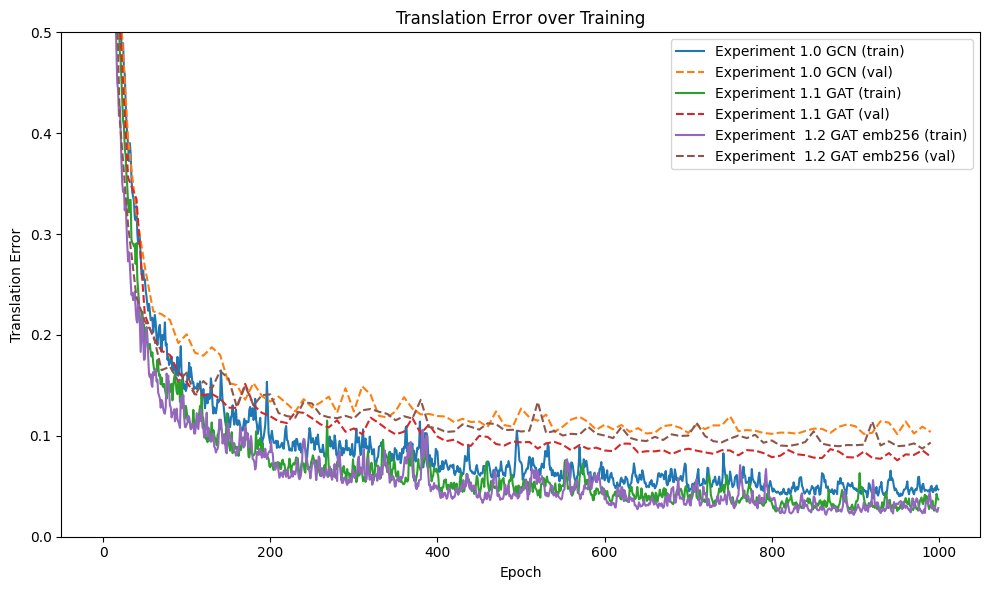

In [33]:
fig, ax = plt.subplots(figsize=(10, 6))
for exp_name, exp_data in data.items():
    ea = exp_data["ea"]
    label = exp_data["label"]
    steps, values = get_scalar_series(ea, "translation_error/train")
    ax.plot(steps, values, label=f"{label} (train)")
    steps, values = get_scalar_series(ea, "translation_error/val")
    ax.plot(steps, values, linestyle="--", label=f"{label} (val)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Translation Error")
ax.set_ylim(0, 0.5)
ax.set_title("Translation Error over Training")
ax.legend()
plt.tight_layout()
plt.show()

## Translation Error (Training vs Validation Side-by-Side)

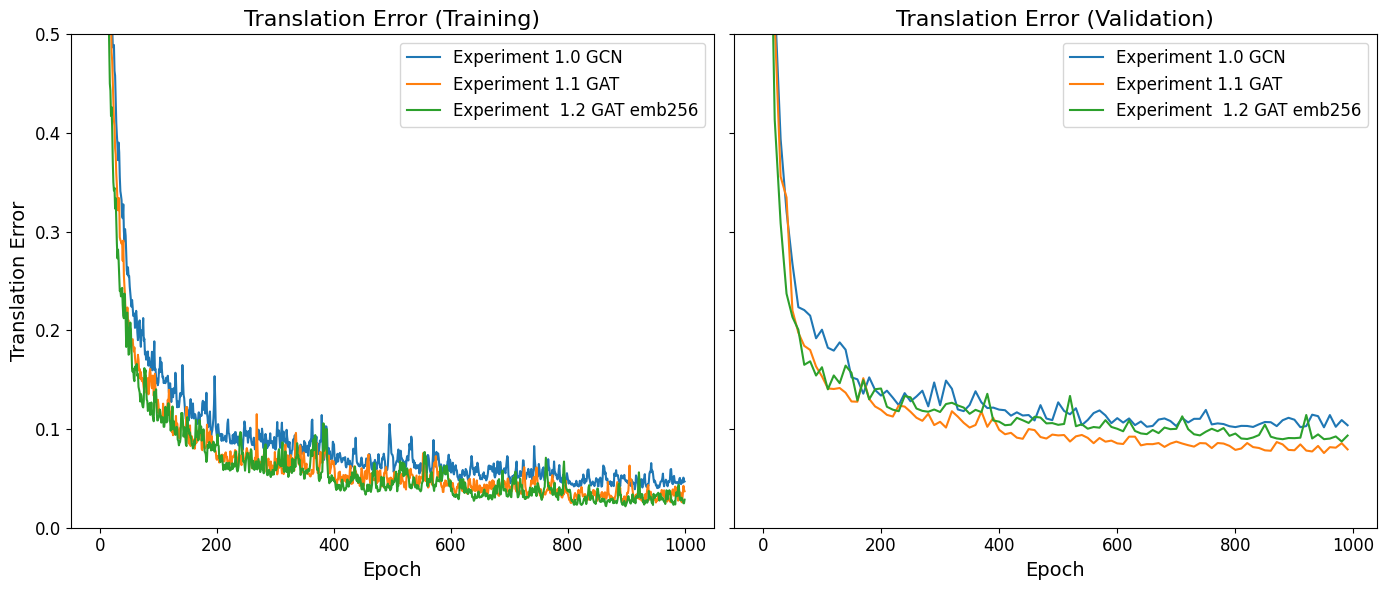

In [38]:
# Define consistent colors for each experiment
exp_colors = {exp_name: plt.cm.tab10(i) for i, exp_name in enumerate(data.keys())}

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Training plot (left)
ax_train = axes[0]
for exp_name, exp_data in data.items():
    ea = exp_data["ea"]
    label = exp_data["label"]
    steps, values = get_scalar_series(ea, "translation_error/train")
    ax_train.plot(steps, values, label=label, color=exp_colors[exp_name])
ax_train.set_xlabel("Epoch", fontsize=14)
ax_train.set_ylabel("Translation Error", fontsize=14)
ax_train.set_ylim(0, 0.5)
ax_train.set_title("Translation Error (Training)", fontsize=16)
ax_train.legend(fontsize=12)
ax_train.tick_params(axis='both', labelsize=12)

# Validation plot (right)
ax_val = axes[1]
for exp_name, exp_data in data.items():
    ea = exp_data["ea"]
    label = exp_data["label"]
    steps, values = get_scalar_series(ea, "translation_error/val")
    ax_val.plot(steps, values, label=label, color=exp_colors[exp_name])
ax_val.set_xlabel("Epoch", fontsize=14)
ax_val.set_ylim(0, 0.5)
ax_val.set_title("Translation Error (Validation)", fontsize=16)
ax_val.legend(fontsize=12)
ax_val.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()

## Translation Error (Training Only)

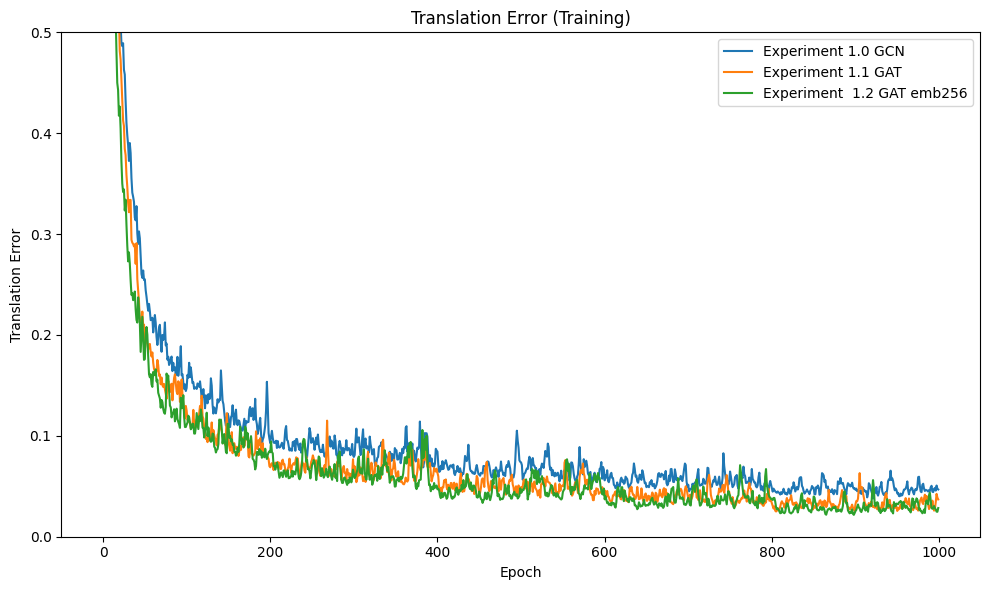

In [35]:
fig, ax = plt.subplots(figsize=(10, 6))
for exp_name, exp_data in data.items():
    ea = exp_data["ea"]
    label = exp_data["label"]
    steps, values = get_scalar_series(ea, "translation_error/train")
    ax.plot(steps, values, label=label)
ax.set_xlabel("Epoch")
ax.set_ylabel("Translation Error")
ax.set_ylim(0, 0.5)
ax.set_title("Translation Error (Training)")
ax.legend()
plt.tight_layout()
plt.show()

## Translation Error (Validation Only)

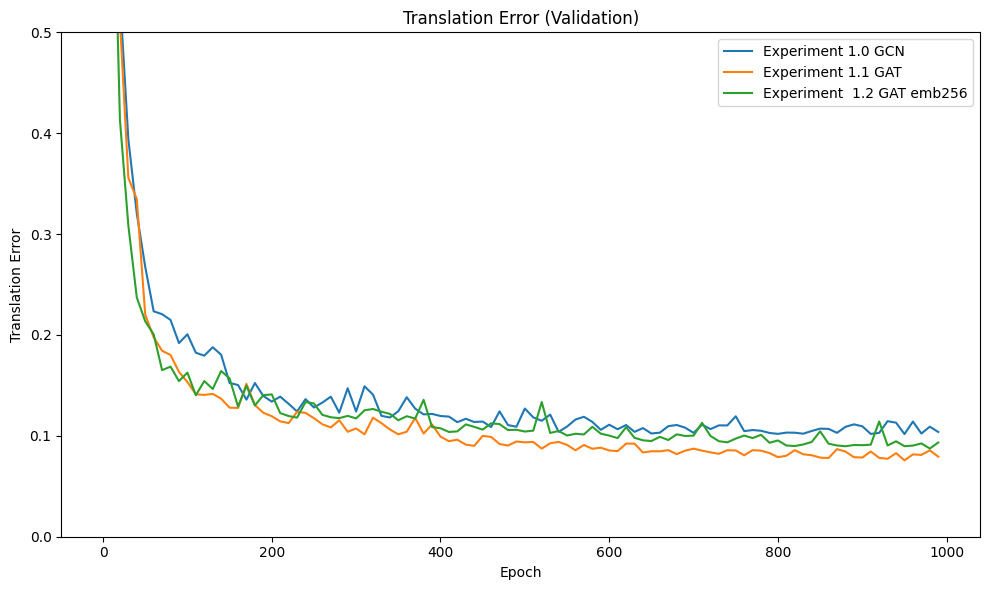

In [36]:
fig, ax = plt.subplots(figsize=(10, 6))
for exp_name, exp_data in data.items():
    ea = exp_data["ea"]
    label = exp_data["label"]
    steps, values = get_scalar_series(ea, "translation_error/val")
    ax.plot(steps, values, label=label)
ax.set_xlabel("Epoch")
ax.set_ylabel("Translation Error")
ax.set_ylim(0, 0.5)
ax.set_title("Translation Error (Validation)")
ax.legend()
plt.tight_layout()
plt.show()

## Final Test Translation Error (Bar Plot)

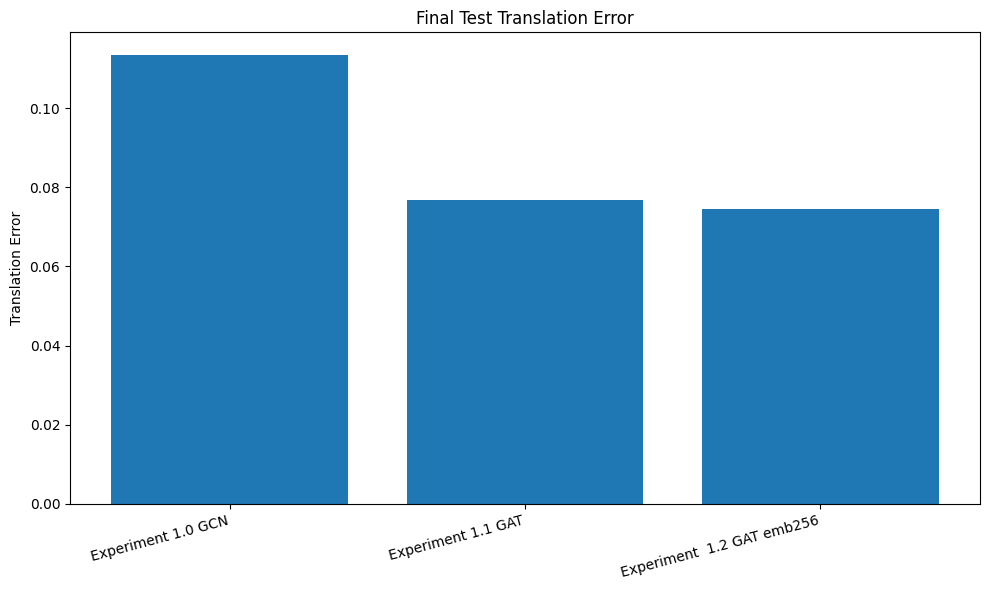

In [37]:
labels = []
test_errors = []
for exp_name, exp_data in data.items():
    ea = exp_data["ea"]
    labels.append(exp_data["label"])
    test_errors.append(get_final_scalar(ea, "translation_error/test"))

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(labels, test_errors)
ax.set_ylabel("Translation Error")
ax.set_title("Final Test Translation Error")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()